<a href="https://colab.research.google.com/github/gehadalsayed665-dot/car-price-prediction/blob/main/Assignment_05_Data_Visualization_%26_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 04: Predicting Stroke Risks – Healthcare Data Pipeline

---

## Assignment Overview

**Domain:** Healthcare / Medical Diagnosis

**Objective:** Prepare a clean, processed, and analysis-ready dataset for stroke prediction. Your goal is to handle messy data, perform exploratory analysis, and apply preprocessing techniques to make the data ready for machine learning.

**Dataset:** Stroke Prediction Dataset from Kaggle

**Target Variable/Column:** `stroke` (0 = No Stroke, 1 = Stroke)

---

## Part 1: Data Loading & Initial Inspection

### Task 1.1: Import Required Libraries

Import the following libraries:
- `pandas` as `pd`
- `numpy` as `np`
- `matplotlib.pyplot` as `plt`
- `seaborn` as `sns`

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Task 1.2: Load the Dataset

Load the `healthcare-dataset-stroke-data.csv` file into a pandas DataFrame named `df`.

**Note:** Make sure the dataset file is in the same directory as this notebook, or provide the correct path.

In [5]:
df=pd.read_csv("/content/healthcare-dataset-stroke-data.csv")

### Task 1.3: Display First 5 Rows

Display the first 5 rows of the dataset to get a quick overview.

In [6]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Task 1.4: Dataset Information

Use `.info()` to identify:
- Data types of each column
- Number of non-null values
- Memory usage

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


### Task 1.5: Statistical Summary

Use `.describe()` to check statistical summaries of numerical columns.

In [8]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


---

## Part 2: Exploratory Data Analysis (EDA) & Visualization

### Task 2.1: Target Variable Analysis

Create a countplot for the `stroke` column to visualize the class distribution.

<Axes: xlabel='stroke', ylabel='count'>

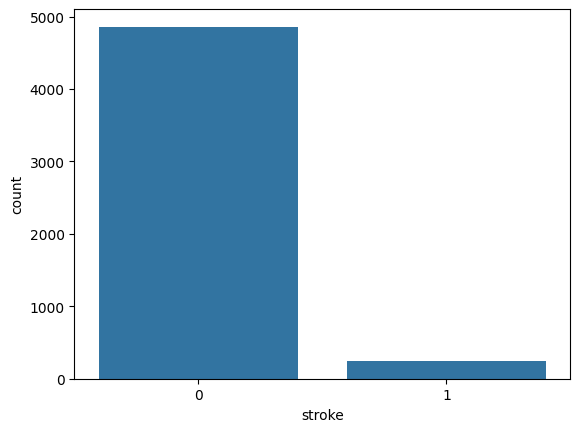

In [9]:
# Countplot for stroke variable
sns.countplot(x='stroke',data=df)

### Task 2.2: Categorical Features Visualization

Create countplots for the following categorical features, split by the target variable (use `hue='stroke'`):
1. `gender`
2. `work_type`
3. `smoking_status`

**Important:**
Plot them side by side. Use subplots to organize your visualizations.

In [10]:
# Countplot for gender, work_type and smoking_status
df=df[df['gender']!='Other']
df['gender'].value_counts()


,count
gender,
Female,2994
Male,2115


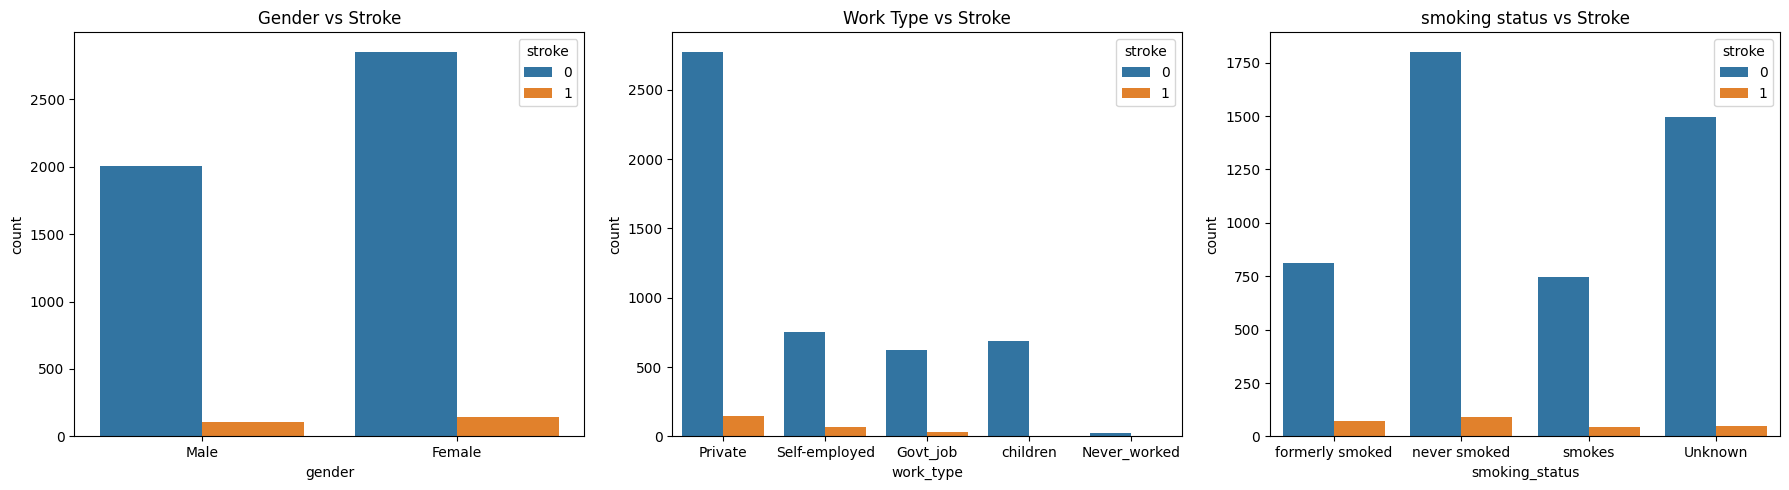

In [40]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
sns.countplot(x='gender',data=df,hue='stroke',ax=axes[0])
sns.countplot(x='work_type',data=df,hue='stroke',ax=axes[1])
sns.countplot(x='smoking_status',data=df,hue='stroke',ax=axes[2])

axes[0].set_title('Gender vs Stroke')
axes[1].set_title('Work Type vs Stroke')
axes[2].set_title('smoking status vs Stroke')
plt.tight_layout()
plt.show()

**Your Observations:** (Optional)
- What patterns do you notice in these categorical features?
- Which categories seem to have higher stroke rates?

In [15]:
"""
1-اغلب الحالات ف التلت رسمومات stroke=0
2-smoking status

"""

'\n\n'

### Task 2.3: Numerical Distributions

Create histograms or KDE plots for the following numerical features:
1. `age`
2. `avg_glucose_level`
3. `bmi`

**Important:**
Plot them side by side. Use subplots to organize your visualizations.

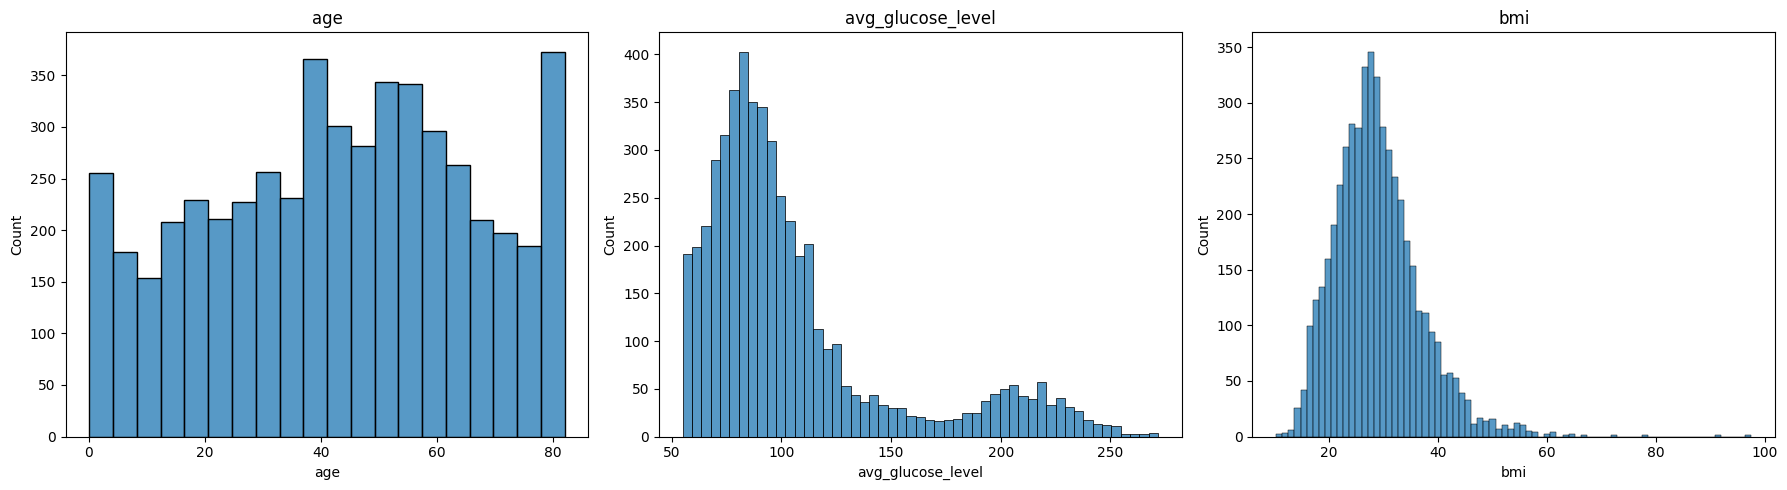

In [42]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
sns.histplot(x='age',data=df,ax=axes[0])
sns.histplot(x='avg_glucose_level',data=df,ax=axes[1])
sns.histplot(x='bmi',data=df,ax=axes[2])
axes[0].set_title('age')
axes[1].set_title('avg_glucose_level')
axes[2].set_title('bmi')
plt.tight_layout()
plt.show()

### Task 2.4: Correlation Analysis

Create a heatmap to show the correlation between numerical variables.

Select only numerical columns: `age`, `hypertension`, `heart_disease`, `avg_glucose_level`, `bmi`, and `stroke`.

In [17]:
# Select features
numerical_cols=[
    'age','hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',  'stroke'
]
corr_matrix=df[numerical_cols].corr()
plt.figure(figsize=(10,7))
sns.histplot(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    fmt='.2f'
)
plt.title('corelation')
# Correlation heatmap


**Your Observations:** (Optional)
- Which features show the strongest correlation with stroke?

In [18]:
"""

"""

'\n\n'

---

## Part 3: Data Preprocessing (Cleaning)

### Task 3.1: Handling Missing Values

Check for missing values in the dataset and identify which columns have them.

In [19]:
# Check for missing values


**Task:** Fill the missing values in the `bmi` column using either the mean or median.

In [20]:
# Fill missing values in bmi

In [21]:
# Verify no missing values remain

### Task 3.2: Handling Duplicates

Check for duplicate rows and remove them if any exist.

In [22]:
# Check for duplicates

In [23]:
# Remove duplicates if any

### Task 3.3: Remove Irrelevant Columns

Drop the `id` column as it has no predictive power.

In [24]:
# Drop the id column

### Task 3.4: Outlier Detection

Use a boxplot to visualize outliers in `avg_glucose_level`.

In [25]:
# Boxplot for avg_glucose_level

In [26]:
# Remove outliers if needed

**Your Observations:** (Optional)
- Did you find outliers ?
- If found, should we remove them ? Why / Why not ?

In [27]:
"""

"""

'\n\n'

---

## Part 4: Data Splitting

### Task 4.1: Separate Features and Target

Separate your dataset into:
- `X`: All features (independent variables)
- `y`: Target variable (`stroke`)

In [28]:
# Separate features and target

### Task 4.2: Train-Test Split

Split the data into training (80%) and testing (20%) sets using `train_test_split` from sklearn.

Use `random_state=42` for reproducibility.

In [29]:
# Import train_test_split

In [30]:
# Split the data

### Task 4.3: Verify Split Shapes

Print the shapes of `X_train`, `X_test`, `y_train`, and `y_test` to verify the split.

In [31]:
# Print shapes

---
## Part 5: Feature Transformation

### Task 5.1: Encoding

Apply Encoding to the following categorical variables:
- `gender`
- `work_type`
- `smoking_status`
- `ever_married`
- `Residence_type`

For each feature, check if it's an **Ordinal** or **Nominal**, **Binary-Categorical** or **Multi-Categorical** Feature.  
Use the suitable encoder based on your obseravations.

In [32]:
# Encoding

---

## Part 6: Feature Scaling

### Task 6.1: Scale Numerical Features

The features `age`, `avg_glucose_level`, and `bmi` have different scales.

Apply `StandardScaler` or `MinMaxScaler` to these three columns.

In [33]:
# Import scaler

In [34]:
# Apply scaling to age, avg_glucose_level, and bmi

---

## Part 7: Handling Class Imbalance

### Task 7.1: Check Current Class Distribution

Display the value counts of the target variable before handling imbalance.

In [35]:
# Check current distribution

### Task 7.2: Handle Unbalanced Data

Apply oversampling, undersampling, or SMOTE to balance the dataset.

Import the appropriate method before applying it.

In [36]:
# Handle unbalanced data (choose your method)

### Task 7.3: Verify Class Balance

Check the value counts of the target variable after oversampling to ensure classes are balanced.

In [37]:
# Verify new distribution

---

## Conclusion

### Task: High-Risk Stroke Patient Persona (Optional)

Based on your exploratory data analysis, write a short paragraph describing the **"persona" of a high-risk stroke patient**. Consider factors like age, glucose levels, work type, and medical history.

In [38]:
"""
# Persona


# Summary


"""

'\n# Persona\n\n\n# Summary\n\n\n'

**Good luck! 🎯**